# 2. Your First Quantum Circuit

In this notebook we build a quantum circuit step by step, explaining
every line, and run it on IBM's Aer simulator.

A quantum circuit is built from:
- **qubits** (quantum bits) — start in state `|0>`
- **gates** — operations that change the qubit's state
- **measurements** — read out a classical 0 or 1 from a qubit

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram

## Step 2: Create a circuit with 1 qubit and 1 classical bit

The classical bit is where we will store the measurement result.

In [2]:
qc = QuantumCircuit(1, 1)
print(qc.draw("text"))

     
  q: 
     
c: 1/
     


## Step 3: Apply a Hadamard (H) gate

The Hadamard gate puts qubit 0 into an equal superposition of
`|0>` and `|1>` — before measurement, it is "both at once".

In [3]:
qc.h(0)
print(qc.draw("text"))

     ┌───┐
  q: ┤ H ├
     └───┘
c: 1/═════
          


## Step 4: Draw the circuit diagram

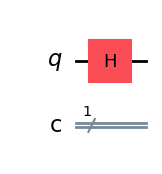

In [4]:
qc.draw("mpl")

## Step 5: Check the exact state before measuring

Probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


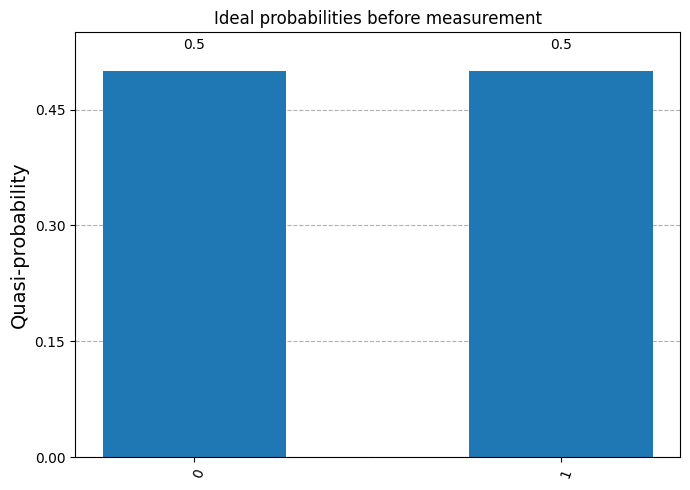

In [5]:
state = Statevector(qc)
probabilities = state.probabilities_dict()
print("Probabilities:", probabilities)

plot_distribution(probabilities, title="Ideal probabilities before measurement")

## Step 6: Add a measurement

`qc.measure(0, 0)` means: measure qubit 0 and store the result in
classical bit 0.

In [6]:
qc.measure(0, 0)
print(qc.draw("text"))

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


## Step 7: Run the circuit on the Aer simulator

`shots=1024` means we repeat the whole experiment 1024 times and
count how often we get each result.

In [7]:
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

Measurement counts: {'1': 530, '0': 494}


## Step 8: Plot the results as a histogram

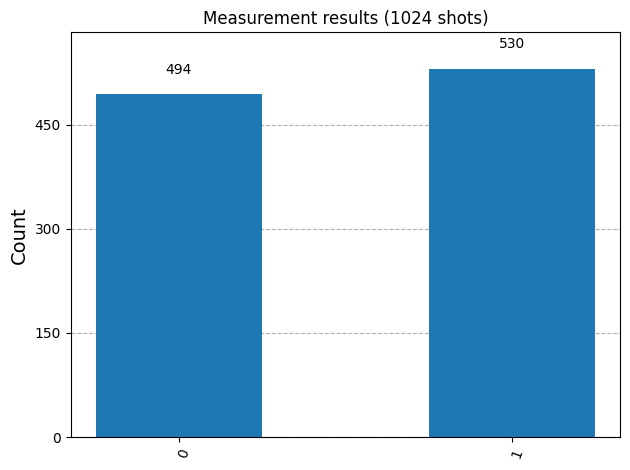

In [8]:
plot_histogram(counts, title="Measurement results (1024 shots)")

Because of the Hadamard gate, you should see roughly 50% `'0'` and
50% `'1'` — the qubit truly had a 50/50 chance of either outcome.